In [1]:
from langchain_groq import ChatGroq
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API")
os.environ["OPENWEATHERMAP_API_KEY"] = os.getenv("OPEN_WEATHER_API")

In [51]:
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0.6
)

supervisor_llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0 # need to be deterministic
)

In [4]:
# make a function which will help us to create agents node
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def create_agents(llm, tools: list, system_message: str):
    # create the prompt
    prompt = ChatPromptTemplate.from_messages([
        ("system" , system_message),
        MessagesPlaceholder(variable_name = "messages")
    ])
    # bind the tools with the llm
    if tools:
      llm_with_tools = llm.bind_tools(tools)
    else:
        llm_with_tools = llm
    return prompt | llm_with_tools

In [5]:
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
import requests

In [44]:
# define a tool which will search for activities in a given destination
@tool(name_or_callable="search_travel_activities", description="Searches for top activities and recommendations for a given destination (city/region only).")
def get_travel_recommendations(destination: str):
    """Fetch travel recommendations for a destination."""
    search = TavilySearch(max_results = 3)
    results = search.invoke(f"Top activities in {destination}")
    return results

In [7]:
get_travel_recommendations.invoke("Cox's-Bazar")

{'query': "Top activities in Cox's-Bazar",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.trip.com/travel-guide/attraction/cox-s-bazar-14721/tourist-attractions',
   'title': "10 Top Attractions in Cox's Bazar (2026) | Trip.com",
   'content': "Popular Family-friendly Attractions in Cox's Bazar. \uf57bOnly view Cox's Bazar. # Things to do in Cox's Bazar (2026). ## Laboni Point Sea Beach. Cox's Bazar3.8 km from downtown. ## Sugondha Sea Beach. ## Radiant Fish World. No. 2 of Family-friendly Attractions in Bangladesh. Embark on a virtual adventure journey at the 8D cinema. Opens at 10:00 AM. ## Himchari Fountain and Hill. Ramu Upazila9.5 km from Cox's Bazar. Cox's Bazar Sea Beach. ## Kolatoli Beach. Kolatoli Beach Cox's Bazar. Cox's Bazar Sadar Upazila3.8 km from Cox's Bazar. ## Himchari National Park. Cox’s Bazar Railway Station South View. ## Cox's Bazar Beach. ## Himchari View Point. ## Himchari Sea Beach. ## Adinath Temple. Moheskhali 

In [8]:
# define a tool to book hotel rooms
@tool(name_or_callable = "hotel-book", description = "Dummy hotel booking tool")
def hotel_book(destination: str, check_in: str, check_out: str):
    """Mock hotel booking function."""
    return f"Hotel booked in {destination} from {check_in} to {check_out}."

In [9]:
# define a tool to get weather updates
@tool(name_or_callable = "weather-tool" , description = "this tool can be used when we need to check for any weather related informations")
def weather_check(city: str):
    "This function fetch weather for any given city name."
    api_key = os.getenv("OPEN_WEATHER_API")
    url =  url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={api_key}&units=metric"
    response = requests.get(url = url)
    return response.json()

In [10]:
response = weather_check.invoke("dhaka")
response

{'coord': {'lon': 90.4074, 'lat': 23.7104},
 'weather': [{'id': 721, 'main': 'Haze', 'description': 'haze', 'icon': '50d'},
  {'id': 501, 'main': 'Rain', 'description': 'moderate rain', 'icon': '10d'}],
 'base': 'stations',
 'main': {'temp': 25.99,
  'feels_like': 25.99,
  'temp_min': 25.99,
  'temp_max': 25.99,
  'pressure': 1004,
  'humidity': 89,
  'sea_level': 1004,
  'grnd_level': 1003},
 'visibility': 4000,
 'wind': {'speed': 3.6, 'deg': 170},
 'rain': {'1h': 2.73},
 'clouds': {'all': 75},
 'dt': 1779436041,
 'sys': {'type': 1,
  'id': 9145,
  'country': 'BD',
  'sunrise': 1779405227,
  'sunset': 1779453391},
 'timezone': 21600,
 'id': 1185241,
 'name': 'Dhaka',
 'cod': 200}

In [52]:
# define all the agents with system prompt and tools
travel_advisor_agent = create_agents(
    llm = llm , tools = [get_travel_recommendations], 
    system_message=(
        "You are a travel expert. "
        "Extract ONLY the destination name (city, region, or country) from the user's request. "
        "Ignore dates like 'from 23 May to 29 May' - they are not needed for the tool. "
        "Then call the 'search_travel_activities' tool with that extracted destination. "
        "Do not add any extra text inside the tool's 'destination' parameter."
    )
)

In [53]:
hotel_booking_agent = create_agents(
    llm = llm, tools = [hotel_book],
    system_message = "You are a hotel booking assistant. Book hotels based on user input. Use hotel-book tool to book hotel room."
)

In [54]:
weather_agent = create_agents(
    llm = llm, tools = [weather_check],
    system_message = "You are a weather assistant. Provide current weather data for requested cities. To get the updated weather informations used tools that you have."
)

In [55]:
weather_response = weather_agent.invoke({
    "messages": [
        ("human" , "Check todays weather in dhaka")
    ]
})
weather_response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'y2grks05y', 'function': {'arguments': '{"city":"dhaka"}', 'name': 'weather-tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 263, 'total_tokens': 279, 'completion_time': 0.051233445, 'completion_tokens_details': None, 'prompt_time': 0.02905226, 'prompt_tokens_details': None, 'queue_time': 0.058042501, 'total_time': 0.080285705}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4ee6-11ea-7923-b33b-30048a263afb-0', tool_calls=[{'name': 'weather-tool', 'args': {'city': 'dhaka'}, 'id': 'y2grks05y', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 263, 'output_tokens': 16, 'total_tokens': 279})

In [15]:
# now the supervisor agent will orchestrates the full workflow by rounting task to appropiate agents.
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [16]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage] , add_messages]
    last_active_agent: str 

In [17]:
# Building the graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

In [18]:
# create the tool node
tool_node = ToolNode(
    tools = [get_travel_recommendations, hotel_book, weather_check]
)

In [56]:
# Supervisor Agent prompt
supervisor_prompt = """
You are a supervisor coordinating travel planning tasks. Based on the user input, route to task specific agents like:
- 'travel_advisor_node' for destination/activity recommendations
- 'hotel_node' for hotel bookings
- 'weather_node' for weather updates

Return ONLY the agent name.
- Do not explain.
- Do not think aloud.
- Do not add extra text.
"""

supervisor_agent = create_agents(
    llm = supervisor_llm, tools = [], system_message = supervisor_prompt
)

In [57]:
response = supervisor_agent.invoke({
    "messages": [
       ("human" , "todays weather in dhaka")
    ]
})
response

AIMessage(content='weather_node', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 3, 'prompt_tokens': 117, 'total_tokens': 120, 'completion_time': 0.014921182, 'completion_tokens_details': None, 'prompt_time': 0.006202961, 'prompt_tokens_details': None, 'queue_time': 0.055720373, 'total_time': 0.021124143}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4ee6-933c-7122-87a8-277471518bf5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 117, 'output_tokens': 3, 'total_tokens': 120})

In [58]:
response.content

'weather_node'

In [59]:
# supervisor agent node
def supervisor_node(state: AgentState):
    last_message = state["messages"][-1]
    agent_names = {"travel_advisor", "weather", "hotel"}
    
    if isinstance(last_message,AIMessage) and getattr(last_message,"name",None) in agent_names:
        return {"last_active_agent": "end"}
    
    result = supervisor_agent.invoke(state)
    return {
        "last_active_agent": result.content.strip()
    }

In [60]:
def travel_advisor_node(state: AgentState):
    node_tools = ToolNode([get_travel_recommendations])
    messages = list(state["messages"])
    
    result = travel_advisor_agent.invoke({"messages" : messages})
    messages.append(result)
    
    while result.tool_calls:
        tool_output = node_tools.invoke({"messages": messages})
        messages.extend(tool_output["messages"])
        result = travel_advisor_agent.invoke({"messages": messages})
        messages.append(result)
        
    return {
        "messages": [AIMessage(content=result.content, name="travel_advisor")]
    }

In [61]:
def weather_node(state: AgentState):
    node_tools = ToolNode([weather_check])
    messages = list(state["messages"])

    result = weather_agent.invoke({"messages": messages})
    messages.append(result)

    while result.tool_calls:
        tool_output = node_tools.invoke({"messages": messages})
        messages.extend(tool_output["messages"])
        result = weather_agent.invoke({"messages": messages})
        messages.append(result)

    return {
        "messages": [AIMessage(content=result.content, name="weather")]
    }

In [62]:
def hotel_node(state: AgentState):
    node_tools = ToolNode([hotel_book])
    messages = list(state["messages"])

    result = hotel_booking_agent.invoke({"messages": messages})
    messages.append(result)

    while result.tool_calls:
        tool_output = node_tools.invoke({"messages": messages})
        messages.extend(tool_output["messages"])
        result = hotel_booking_agent.invoke({"messages": messages})
        messages.append(result)

    return {
        "messages": [AIMessage(content=result.content, name="hotel")]
    }

In [63]:
def route(state: AgentState) -> str:
    valid = {"travel_advisor_node", "weather_node", "hotel_node", "end"}
    decision = state["last_active_agent"].strip()
    if decision not in valid:
        print(f"[route] Unexpected supervisor output: {repr(decision)} -> defaulting to end")
        return "end"
    return decision

In [64]:
# create the full graph
graph = StateGraph(state_schema = AgentState)

# add nodes
graph.add_node("supervisor_node" , supervisor_node)
graph.add_node("travel_advisor_node" , travel_advisor_node)
graph.add_node("weather_node" , weather_node)
graph.add_node("hotel_node" , hotel_node)

# add edges
graph.add_edge(START , "supervisor_node")
graph.add_conditional_edges(
    "supervisor_node", route , {
        "travel_advisor_node": "travel_advisor_node",
        "weather_node": "weather_node",
        "hotel_node": "hotel_node",
        "end": END
    }
)
graph.add_edge("travel_advisor_node", "supervisor_node")
graph.add_edge("weather_node", "supervisor_node")
graph.add_edge("hotel_node", "supervisor_node")

workflow = graph.compile()

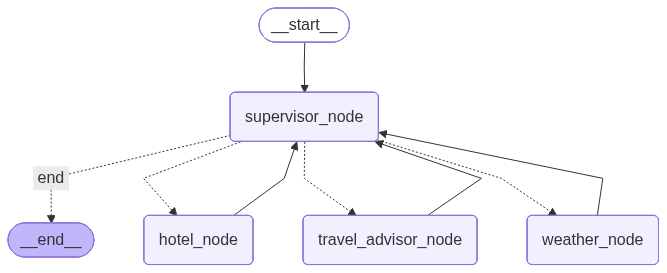

In [65]:
workflow

In [74]:
final_result = workflow.invoke({
    "messages": [
        HumanMessage(content = "plan a trip to coxs bazar with a weather update for next week.")
    ]
})

In [75]:
final_result

{'messages': [HumanMessage(content='plan a trip to coxs bazar with a weather update for next week.', additional_kwargs={}, response_metadata={}, id='e6df7fbd-e01f-4c09-8a09-50443fd2f384'),
  AIMessage(content="Next week's weather forecast for Cox's Bazar is expected to be mostly cloudy with a high temperature of 31 degrees Celsius and a low of 31 degrees Celsius. The humidity is expected to be around 70% with a wind speed of 6.69 meters per second. \n\nAs for planning a trip to Cox's Bazar, here are some suggestions:\n\n1. Best Time to Visit: The best time to visit Cox's Bazar is during the winter months (October to February) when the weather is cooler and more pleasant.\n2. Places to Visit: Some popular places to visit in Cox's Bazar include the Cox's Bazar Beach, Himchari National Park, and the Aggmeda Khyang monastery.\n3. Activities: You can enjoy various activities such as swimming, sunbathing, and water sports on the beach. You can also take a boat ride or go on a trek in the nea

In [76]:
for message in final_result["messages"]:
    print(f"{message.type}: {message.content} \n\n")

human: plan a trip to coxs bazar with a weather update for next week. 


ai: Next week's weather forecast for Cox's Bazar is expected to be mostly cloudy with a high temperature of 31 degrees Celsius and a low of 31 degrees Celsius. The humidity is expected to be around 70% with a wind speed of 6.69 meters per second. 

As for planning a trip to Cox's Bazar, here are some suggestions:

1. Best Time to Visit: The best time to visit Cox's Bazar is during the winter months (October to February) when the weather is cooler and more pleasant.
2. Places to Visit: Some popular places to visit in Cox's Bazar include the Cox's Bazar Beach, Himchari National Park, and the Aggmeda Khyang monastery.
3. Activities: You can enjoy various activities such as swimming, sunbathing, and water sports on the beach. You can also take a boat ride or go on a trek in the nearby hills.
4. Accommodation: There are many hotels and resorts in Cox's Bazar that cater to different budgets and preferences. You can choo